# 07 — Abundances with `compute_abundances`

End-to-end abundance tutorial on a single G395M spectrum.  The whole
workflow — dust correction, T_e, n_e, ICFs, posterior sampling — is
wrapped behind one call: `jwspecabund.compute_abundances(result, z=...)`.

This notebook runs each method (auto / direct / strong-line / forward)
on the same fit and overlays the resulting 12+log(O/H) posteriors.

Source: EXCELS UDS04 ID 63107 at z = 8.271.


In [5]:
import jwspecfit
import jwspecmcmc
import jwspecabund
import matplotlib.pyplot as plt
import numpy as np
import numpyro
numpyro.set_host_device_count(6)

print(f'jwspecfit   v{jwspecfit.__version__}')
print(f'jwspecmcmc  v{jwspecmcmc.__version__}')
print(f'jwspecabund v{jwspecabund.__version__}')


jwspecfit   v1.0.1
jwspecmcmc  v1.0.1
jwspecabund v1.0.1


## 1. Load and inspect the spectrum


In [6]:
z = 8.271
spec = jwspecfit.read_fits(
    '../../data/excels-uds04-v4_g395m-f290lp_3543_63107.spec.fits',
    z=z,
)
print(f'Grating  : {spec.grating}')
print(f'Pixels   : {spec.n_pix}')
print(f'Range    : {spec.wave_um.min():.3f} - {spec.wave_um.max():.3f} um')


Grating  : G395M
Pixels   : 1661
Range    : 2.680 - 5.510 um


In [7]:
fig = jwspecfit.plot_spectrum_interactive(spec, flux_unit='fnu')
fig.show()


## 2. Fit emission lines (MCMC, BIC broad-Balmer)

`jwspecmcmc.fit_lines` returns an `MCMCResult` whose flux posteriors
feed straight into `compute_abundances` — the abundance code uses
the per-line samples to propagate errors automatically.


In [8]:
mcmc_result = jwspecmcmc.fit_lines(
    spec, z=z,
    sampler='nuts',moving_average=True,
    n_warmup=500, n_samples_nuts=2000, n_chains=6,
)
result = mcmc_result.to_fit_result()  # for plotting

print(f'Selected model: {mcmc_result.selected_model}')
print(f'chi2/dof      : {result.chi2:.2f}')
print(f'R-hat max     : {mcmc_result.convergence["r_hat_max"]:.3f}')
print(f'ESS  min      : {mcmc_result.convergence["ess_min"]:.0f}')


Resolving power: R = 1000
Resolving power: R = 1000
Resolving power: R = 1000


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

Selected model: narrow
chi2/dof      : 0.85
R-hat max     : 1.001
ESS  min      : 3179


/Users/raunaqrai/Documents/phd/y1/jwspecfit/src/jwspecfit/plotting.py:376: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



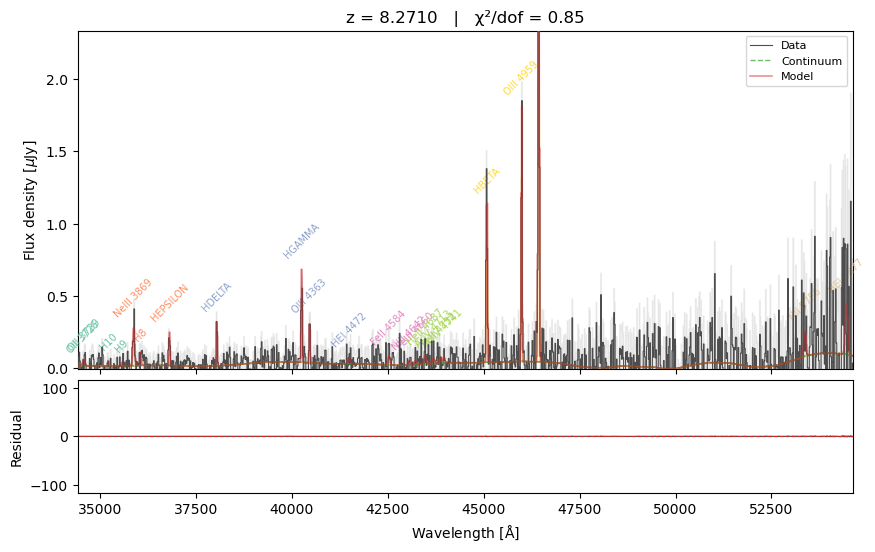

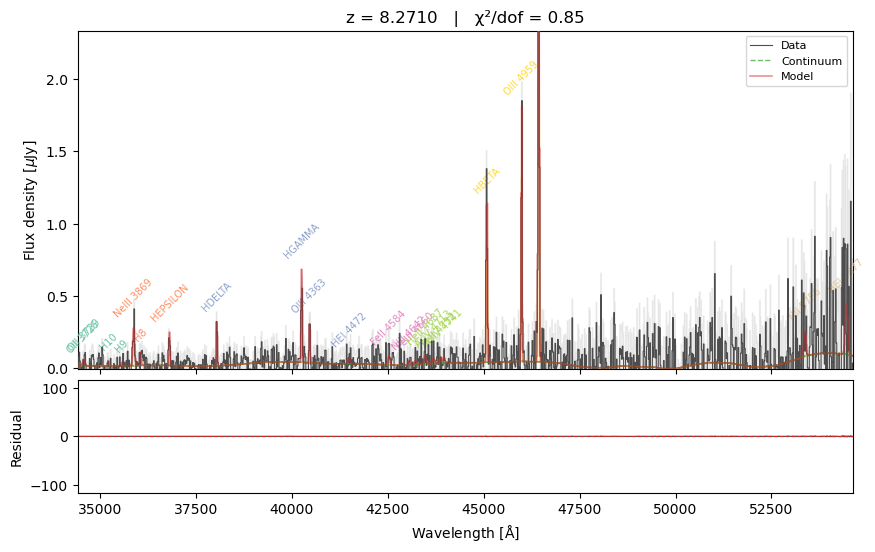

In [9]:
fig = jwspecfit.plot_fit(result, flux_unit='fnu', y_pad=0.5)
fig

## 3. One-call abundance: auto mode

`method='auto'` uses the direct T_e method when [O III] 4363 is
detected (SNR > `snr_auroral`, default 3) and falls back to
Sanders+25 strong-line otherwise.  A_V is derived from the
Balmer decrement (multi-line, anchor = `balmer_anchor`).


In [10]:
abund = jwspecabund.compute_abundances(
    mcmc_result, z=z,
    method='auto',
    balmer_anchor='HBETA',
    dust_law='cardelli',
    n_mc=500,
)
print(abund.summary())



N/O ICF REASONING (icf_method='auto')

--- Detected nitrogen ions ---
  N+/H+: not detected
  N++/H+: not detected
  N+++/H+: not detected
  N4+/H+: not detected

--- Detected oxygen ions ---
  O+/H+: not detected
  O++/H+: 7.1575e-06

--- Available diagnostics ---
  logU:   not available
  Z/Zsun: 0.01461377481079317

--- Requested method: 'auto' ---

--- Method eligibility ---
  martinez25: NOT ELIGIBLE (missing logU)
  direct_sum (Tier 1 — Np+Npp+Nppp/OH): NOT ELIGIBLE (need N+ and N++ or N+++)
  direct_sum (Tier 2/3 — UV N/O++): NOT ELIGIBLE (need N++ or N+++ and O++)
  izotov06 (Tier 4 — N+/O+ fallback): NOT ELIGIBLE (need N+ and O+)

--- Final selection ---
  N/O: could not be computed (no eligible method with detected ions)



Strong-line (posterior): 100%|██████████| 1000/1000 [00:00<00:00, 15416.66it/s]

AbundanceResult (method=direct)
  12+log(O/H) = 6.855 +/- (0.14549624749250079, 0.15928060725727544)
  log(N/O)    = FAILED — no nitrogen ions detected
  log(C/O)    = FAILED — no carbon ions detected (CII]/CIII]/CIV missing)
  log(S/O)    = FAILED — no S+ or S++ ions detected ([SII]/[SIII] missing)
  log(Ne/O)   = -0.551 +/- (0.09343912860262693, 0.08742263252874144)
  log(Ar/O)   = FAILED — no Ar++ ion detected ([ArIII] 7136 missing)
  T_e(high)   = 40837 +/- (10752.738433694318, 16214.514298429975) K
  T_e(low)    = 29732 +/- (6967.774505033918, 10507.005265382628) K
  n_e         = 300 cm^-3
  n_e(low)    = 300 cm^-3
  n_e(high)   = 300 cm^-3
  A_V         = 0.000 +/- 0.576

Ionisation correction factors:
  Ne/O: ICF = 1.0000 (Izotov+06)  raw = -0.550  →  corrected = -0.550  (Δ = +0.000 dex)

Ionic abundances:
  O++/H+        = 7.1575e-06
  Ne++/H+       = 2.0158e-06
  Excluded    = ['OII_3726', 'OII_3729', 'H10', 'H9', 'H8', 'HEI_4472', 'FeII_4584', 'NIII_4642', 'FeIII_4660', 'HeI

Useful attributes on the returned `AbundanceResult`:

| Field | Meaning |
|-------|---------|
| `OH`, `OH_err`         | 12 + log(O/H), with (lo, hi) 68 % CI |
| `NO`, `NO_err`         | log(N/O) (ICF-corrected) |
| `Te_high`, `Te_low`    | T_e for high- and low-ionisation zones (K) |
| `ne_low`/`ne_mid`/`ne_high` | electron densities by ionisation zone |
| `Av`, `Av_err`         | dust attenuation derived from Balmer decrement |
| `OH_posterior`         | full MC posterior of 12+log(O/H) |
| `ionic`                | dict of ionic abundances (e.g. O+/H+) |
| `failures`             | reasons specific ratios couldn't be derived |


## 4. Method comparison

Run the same data through three independent abundance machinery and
overlay the posteriors.  The forward model takes a few minutes —
skip the cell if you don't need it.


In [11]:
abund_direct = jwspecabund.compute_abundances(
    mcmc_result, z=z, method='direct', n_mc=500,
)
abund_strong = jwspecabund.compute_abundances(
    mcmc_result, z=z, method='strong_line', n_mc=500,
)

for label, a in [('direct', abund_direct), ('strong-line', abund_strong)]:
    print(f'{label:>12s}  12+log(O/H) = {a.OH:.3f}  +/- {a.OH_err}')



N/O ICF REASONING (icf_method='auto')

--- Detected nitrogen ions ---
  N+/H+: not detected
  N++/H+: not detected
  N+++/H+: not detected
  N4+/H+: not detected

--- Detected oxygen ions ---
  O+/H+: not detected
  O++/H+: 7.1575e-06

--- Available diagnostics ---
  logU:   not available
  Z/Zsun: 0.01461377481079317

--- Requested method: 'auto' ---

--- Method eligibility ---
  martinez25: NOT ELIGIBLE (missing logU)
  direct_sum (Tier 1 — Np+Npp+Nppp/OH): NOT ELIGIBLE (need N+ and N++ or N+++)
  direct_sum (Tier 2/3 — UV N/O++): NOT ELIGIBLE (need N++ or N+++ and O++)
  izotov06 (Tier 4 — N+/O+ fallback): NOT ELIGIBLE (need N+ and O+)

--- Final selection ---
  N/O: could not be computed (no eligible method with detected ions)



Strong-line (posterior): 100%|██████████| 1000/1000 [00:00<00:00, 15747.75it/s]

      direct  12+log(O/H) = 6.855  +/- (0.14549624749250079, 0.15928060725727544)
 strong-line  12+log(O/H) = 7.022  +/- (0.04105281711806441, 0.05704523378453619)


In [13]:
# Forward model (Cullen+25): joint Bayesian fit to all line ratios.
# Slower but produces full joint posteriors over (Z, logU, Av, Te).
abund_forward = jwspecabund.compute_abundances(
    mcmc_result, z=z, method='forward',
    forward_sampler='emcee',
    forward_n_walkers=32, forward_n_steps=3000, forward_n_burn=1000,
    forward_progress=True,
)
print(f'forward     12+log(O/H) = {abund_forward.OH:.3f}  +/- {abund_forward.OH_err}')


100%|██████████| 3000/3000 [01:10<00:00, 42.32it/s]

forward     12+log(O/H) = 6.840  +/- (0.1712822414812436, 0.196054846701883)


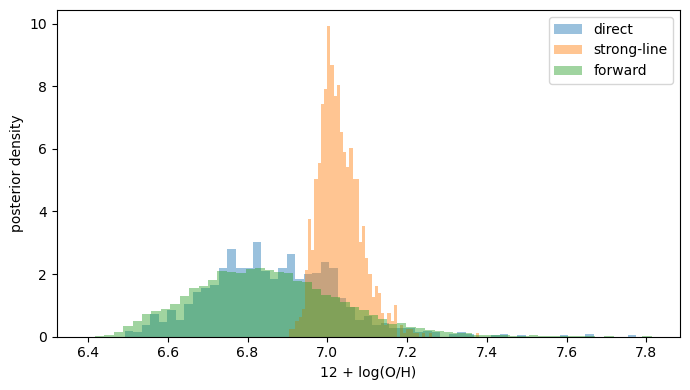

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, a, c in [
    ('direct',      abund_direct,  'C0'),
    ('strong-line', abund_strong,  'C1'),
    ('forward',     abund_forward, 'C2'),
]:
    if a.OH_posterior is None:
        continue
    ax.hist(
        a.OH_posterior, bins=60, alpha=0.45,
        density=True, label=label, color=c,
    )
ax.set_xlabel('12 + log(O/H)')
ax.set_ylabel('posterior density')
ax.legend()
fig.tight_layout()


## 5. Inspect the dust correction

When `Av` is not supplied, `compute_abundances` derives it from
the Balmer decrement.  Switch laws to see how sensitive the
answer is.


In [15]:
for law in ('salim', 'cardelli'):
    a = jwspecabund.compute_abundances(
        mcmc_result, z=z, method='auto', dust_law=law, n_mc=500,
    )
    print(f'{law:>9s}  A_V = {a.Av:.3f} +/- {a.Av_err:.3f}   '
          f'12+log(O/H) = {a.OH:.3f}')



N/O ICF REASONING (icf_method='auto')

--- Detected nitrogen ions ---
  N+/H+: not detected
  N++/H+: not detected
  N+++/H+: not detected
  N4+/H+: not detected

--- Detected oxygen ions ---
  O+/H+: not detected
  O++/H+: 7.1575e-06

--- Available diagnostics ---
  logU:   not available
  Z/Zsun: 0.01461377481079317

--- Requested method: 'auto' ---

--- Method eligibility ---
  martinez25: NOT ELIGIBLE (missing logU)
  direct_sum (Tier 1 — Np+Npp+Nppp/OH): NOT ELIGIBLE (need N+ and N++ or N+++)
  direct_sum (Tier 2/3 — UV N/O++): NOT ELIGIBLE (need N++ or N+++ and O++)
  izotov06 (Tier 4 — N+/O+ fallback): NOT ELIGIBLE (need N+ and O+)

--- Final selection ---
  N/O: could not be computed (no eligible method with detected ions)



Strong-line (posterior): 100%|██████████| 1000/1000 [00:00<00:00, 15450.00it/s]


    salim  A_V = 0.000 +/- 0.407   12+log(O/H) = 6.855

N/O ICF REASONING (icf_method='auto')

--- Detected nitrogen ions ---
  N+/H+: not detected
  N++/H+: not detected
  N+++/H+: not detected
  N4+/H+: not detected

--- Detected oxygen ions ---
  O+/H+: not detected
  O++/H+: 7.1575e-06

--- Available diagnostics ---
  logU:   not available
  Z/Zsun: 0.01461377481079317

--- Requested method: 'auto' ---

--- Method eligibility ---
  martinez25: NOT ELIGIBLE (missing logU)
  direct_sum (Tier 1 — Np+Npp+Nppp/OH): NOT ELIGIBLE (need N+ and N++ or N+++)
  direct_sum (Tier 2/3 — UV N/O++): NOT ELIGIBLE (need N++ or N+++ and O++)
  izotov06 (Tier 4 — N+/O+ fallback): NOT ELIGIBLE (need N+ and O+)

--- Final selection ---
  N/O: could not be computed (no eligible method with detected ions)



Strong-line (posterior): 100%|██████████| 1000/1000 [00:00<00:00, 15396.29it/s]

 cardelli  A_V = 0.000 +/- 0.576   12+log(O/H) = 6.855


In [16]:
# Skip the dust correction entirely (use observed fluxes)
abund_nodust = jwspecabund.compute_abundances(
    mcmc_result, z=z, method='auto', dust_correct=False, n_mc=500,
)
print(abund_nodust.summary())



N/O ICF REASONING (icf_method='auto')

--- Detected nitrogen ions ---
  N+/H+: not detected
  N++/H+: not detected
  N+++/H+: not detected
  N4+/H+: not detected

--- Detected oxygen ions ---
  O+/H+: not detected
  O++/H+: 7.1575e-06

--- Available diagnostics ---
  logU:   not available
  Z/Zsun: 0.01461377481079317

--- Requested method: 'auto' ---

--- Method eligibility ---
  martinez25: NOT ELIGIBLE (missing logU)
  direct_sum (Tier 1 — Np+Npp+Nppp/OH): NOT ELIGIBLE (need N+ and N++ or N+++)
  direct_sum (Tier 2/3 — UV N/O++): NOT ELIGIBLE (need N++ or N+++ and O++)
  izotov06 (Tier 4 — N+/O+ fallback): NOT ELIGIBLE (need N+ and O+)

--- Final selection ---
  N/O: could not be computed (no eligible method with detected ions)



Strong-line (posterior): 100%|██████████| 1000/1000 [00:00<00:00, 16388.03it/s]

AbundanceResult (method=direct)
  12+log(O/H) = 6.855 +/- (0.14549624749250079, 0.15928060725727544)
  log(N/O)    = FAILED — no nitrogen ions detected
  log(C/O)    = FAILED — no carbon ions detected (CII]/CIII]/CIV missing)
  log(S/O)    = FAILED — no S+ or S++ ions detected ([SII]/[SIII] missing)
  log(Ne/O)   = -0.551 +/- (0.09343912860262693, 0.08742263252874144)
  log(Ar/O)   = FAILED — no Ar++ ion detected ([ArIII] 7136 missing)
  T_e(high)   = 40837 +/- (10752.738433694318, 16214.514298429975) K
  T_e(low)    = 29732 +/- (6967.774505033918, 10507.005265382628) K
  n_e         = 300 cm^-3
  n_e(low)    = 300 cm^-3
  n_e(high)   = 300 cm^-3

Ionisation correction factors:
  Ne/O: ICF = 1.0000 (Izotov+06)  raw = -0.550  →  corrected = -0.550  (Δ = +0.000 dex)

Ionic abundances:
  O++/H+        = 7.1575e-06
  Ne++/H+       = 2.0158e-06
  Excluded    = ['OII_3726', 'OII_3729', 'H10', 'H9', 'H8', 'HEI_4472', 'FeII_4584', 'NIII_4642', 'FeIII_4660', 'HeII_4687', 'ArIV_4713', 'FeII_4732

## 6. Per-line table

If you need the dust-corrected fluxes for a paper table, pull
them straight off the `MCMCResult` (un-corrected) and pass through
`jwspecabund.dust.apply_dust_correction` with `Av = abund.Av`.


In [17]:
from jwspecabund.dust import dust_correct_fluxes
from jwspecfit.lines import REST_LINES_A

# {name: (flux, err, rest_wave_A)}  — the format dust_correct_fluxes wants
line_fluxes = {
    n: (
        lr.flux,
        0.5 * (lr.flux_err[0] + lr.flux_err[1]),
        REST_LINES_A[n],
    )
    for n, lr in mcmc_result.lines.items()
    if n in REST_LINES_A
}

corrected = dust_correct_fluxes(line_fluxes, Av=abund.Av, law='salim')

header = f'{"Line":<14s} {"obs flux":>12s} {"dust-corr":>12s} {"SNR":>7s}'
print(header)
print('-' * len(header))
for name in sorted(line_fluxes):
    snr = mcmc_result.lines[name].snr
    f_obs = line_fluxes[name][0]
    f_dc  = corrected[name][0]
    print(f'{name:<14s} {f_obs:12.3e} {f_dc:12.3e} {snr:7.1f}')


Line               obs flux    dust-corr     SNR
------------------------------------------------
ArIV_4713         4.552e-20    4.552e-20     1.1
ArIV_4741         4.480e-20    4.480e-20     1.1
FeIII_4660        3.866e-20    3.866e-20     1.0
FeII_4584         6.821e-20    6.821e-20     1.3
FeII_4732         4.679e-20    4.679e-20     1.1
H10               3.234e-20    3.234e-20     1.2
H8                6.378e-20    6.378e-20     1.7
H9                1.624e-20    1.624e-20     1.0
HBETA             6.869e-19    6.869e-19    12.8
HDELTA            2.112e-19    2.112e-19     5.7
HEI_4472          5.410e-20    5.410e-20     1.2
HEI_5877          2.877e-19    2.877e-19     1.3
HEPSILON          1.531e-19    1.531e-19     4.2
HGAMMA            3.937e-19    3.937e-19     8.4
HeII_4687         7.127e-20    7.127e-20     1.3
NIII_4642         3.415e-20    3.415e-20     1.0
NII_5756          1.401e-19    1.401e-19     1.3
NeIII_3869        3.795e-19    3.795e-19     5.2
OIII_4363         1.

## See also

- [Notebook 08](08_nitrogen.ipynb) — combined-grating nitrogen with ICFs.
- [Notebook 09](09_uv_abundances.ipynb) — UV-only C/O and N/O.
- [Abundance methodology](../abundance_methodology.md) — what the code is
  doing under the hood.
